In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import arff
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)

In [2]:
!wget -O asd_children.zip "https://archive.ics.uci.edu/static/public/419/autistic+spectrum+disorder+screening+data+for+children.zip"
!unzip -o asd_children.zip

data, meta = arff.loadarff('Autism-Child-Data.arff')
df = pd.DataFrame(data)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.decode('utf-8')

df.head()

--2026-04-02 19:57:46--  https://archive.ics.uci.edu/static/public/419/autistic+spectrum+disorder+screening+data+for+children.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘asd_children.zip’

asd_children.zip        [ <=>                ]  39.14K  --.-KB/s    in 0.05s   

2026-04-02 19:57:46 (806 KB/s) - ‘asd_children.zip’ saved [40081]

Archive:  asd_children.zip
  inflating: Autism-Child-Data.arff  
  inflating: Autism-Screening-Child-Data Description.docx  


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,0,1,1,0,1,0,0,...,m,Others,no,no,Jordan,no,5.0,4-11 years,Parent,NO
1,1,1,0,0,1,1,0,1,0,0,...,m,Middle Eastern,no,no,Jordan,no,5.0,4-11 years,Parent,NO
2,1,1,0,0,0,1,1,1,0,0,...,m,?,no,no,Jordan,yes,5.0,4-11 years,?,NO
3,0,1,0,0,1,1,0,0,0,1,...,f,?,yes,no,Jordan,no,4.0,4-11 years,?,NO
4,1,1,1,1,1,1,1,1,1,1,...,m,Others,yes,no,United States,no,10.0,4-11 years,Parent,YES


In [3]:
df['Class/ASD'] = df['Class/ASD'].map({'NO': 0, 'YES': 1})
df['Class/ASD'].value_counts()

,count
Class/ASD,
0,151
1,141


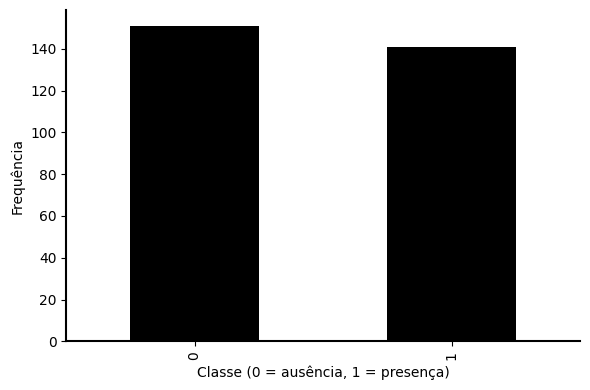

In [4]:
plt.figure(figsize=(6,4))
df["Class/ASD"].value_counts().sort_index().plot(kind="bar", color="black")

plt.xlabel("Classe (0 = ausência, 1 = presença)")
plt.ylabel("Frequência")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(False)

plt.tight_layout()
plt.savefig("fig1.png", dpi=300)
plt.show()

In [5]:
X = df.drop("Class/ASD", axis=1)
y = df["Class/ASD"]

X = pd.get_dummies(X, drop_first=True)
X = X.drop("result", axis=1, errors="ignore")
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (204, 81)
Teste: (88, 81)


In [6]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy Logística:", model.score(X_test, y_test))
print(classification_report(y_test, y_pred))

Accuracy Logística: 0.9886363636363636
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        51
           1       1.00      0.97      0.99        37

    accuracy                           0.99        88
   macro avg       0.99      0.99      0.99        88
weighted avg       0.99      0.99      0.99        88



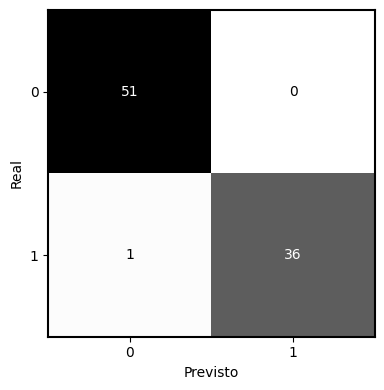

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Greys")

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max()/2 else "black"
        plt.text(j, i, cm[i, j], ha="center", va="center", color=color)

plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
plt.xlabel("Previsto")
plt.ylabel("Real")

for spine in plt.gca().spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.savefig("fig2.png", dpi=300)
plt.show()

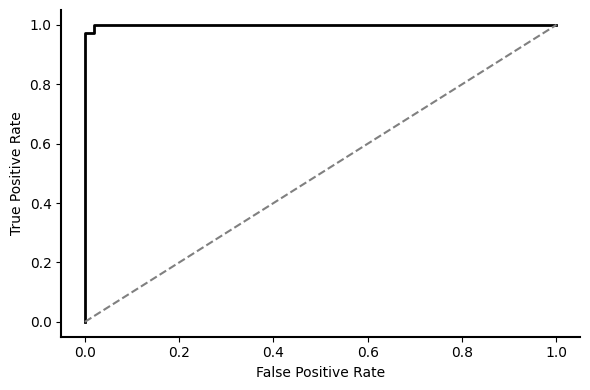

AUC Logística: 0.9994700582935877


In [8]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6,4))
plt.plot(fpr_lr, tpr_lr, color="black", linewidth=2)
plt.plot([0,1],[0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(False)

plt.tight_layout()
plt.savefig("fig3.png", dpi=300)
plt.show()

print("AUC Logística:", auc_lr)

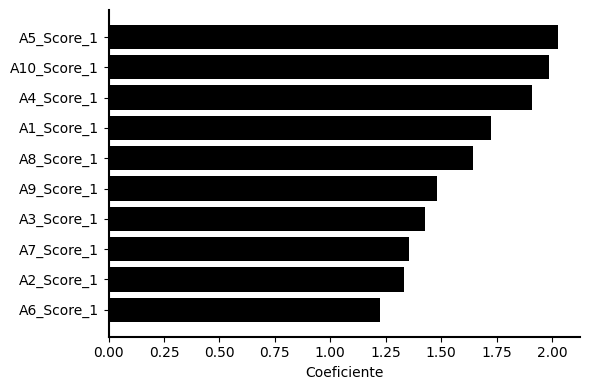

In [9]:
coef = model.coef_[0]
features = X.columns

coef_df = pd.DataFrame({
    "Variável": features,
    "Coeficiente": coef
})

coef_df["Importância"] = np.abs(coef_df["Coeficiente"])
coef_df = coef_df.sort_values("Importância", ascending=False)

top = coef_df.head(10)

plt.figure(figsize=(6,4))
plt.barh(top["Variável"], top["Coeficiente"], color="black")

plt.xlabel("Coeficiente")
plt.gca().invert_yaxis()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(False)

plt.tight_layout()
plt.savefig("fig4.png", dpi=300)
plt.show()

In [10]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print("Accuracy Random Forest:", rf.score(X_test, y_test))
print(classification_report(y_test, rf_pred))

Accuracy Random Forest: 0.9090909090909091
              precision    recall  f1-score   support

           0       0.96      0.88      0.92        51
           1       0.85      0.95      0.90        37

    accuracy                           0.91        88
   macro avg       0.91      0.91      0.91        88
weighted avg       0.91      0.91      0.91        88



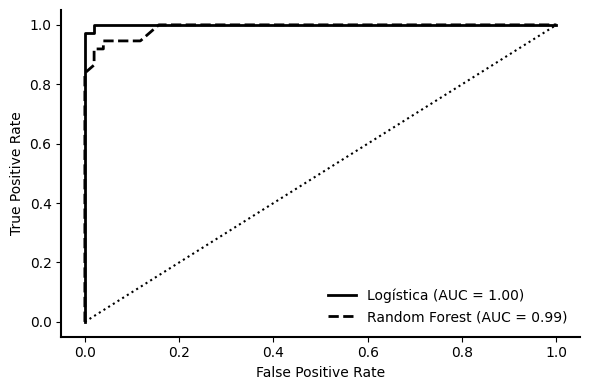

In [11]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,4))

plt.plot(fpr_lr, tpr_lr, color="black", linewidth=2, linestyle="-")
plt.plot(fpr_rf, tpr_rf, color="black", linewidth=2, linestyle="--")
plt.plot([0,1],[0,1], linestyle=":", color="black")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(False)

plt.legend([
    f"Logística (AUC = {auc_lr:.2f})",
    f"Random Forest (AUC = {auc_rf:.2f})"
], frameon=False)

plt.tight_layout()
plt.savefig("fig5.png", dpi=300)
plt.show()

<Figure size 600x400 with 0 Axes>

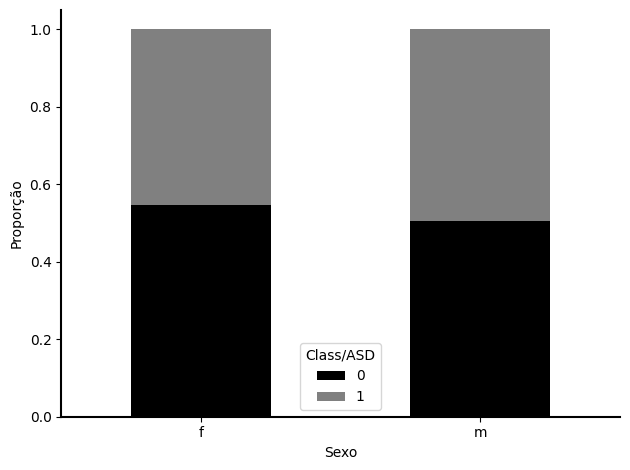

In [12]:
tab = pd.crosstab(df["gender"], df["Class/ASD"], normalize="index")

plt.figure(figsize=(6,4))
tab.plot(kind="bar", stacked=True, color=["black","gray"])

plt.xlabel("Sexo")
plt.ylabel("Proporção")

plt.xticks(rotation=0)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(False)

plt.tight_layout()
plt.savefig("fig6.png", dpi=300)
plt.show()

In [13]:
from scipy.stats import chi2_contingency


tab_abs = pd.crosstab(df["gender"], df["Class/ASD"])

chi2, p, dof, expected = chi2_contingency(tab_abs)

print("Qui-quadrado:", chi2)
print("p-valor:", p)

Qui-quadrado: 0.28447044555963774
p-valor: 0.5937859868520012
